# Notebook Purpose

**Pairs Trading Mean Reversion** notebook for **highly correlated assets** (>0.7 corr).

Loads 2 CSV prices → Linear regression → Spread analysis → Z-score trading signals (buy/sell/neutral).

In [36]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [37]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ASSET1_FILE = "../../data/sp500_top30/MA_1d_2017-01-01_2026-03-01.csv"
ASSET2_FILE = "../../data/sp500_top30/V_1d_2017-01-01_2026-03-01.csv"

# Extract tickers from filenames
asset1_ticker = ASSET1_FILE.split('/')[-1].split('_')[0]
asset2_ticker = ASSET2_FILE.split('/')[-1].split('_')[0]

df1 = pd.read_csv(ASSET1_FILE, parse_dates=['Date']).set_index('Date')['Adj Close'].rename(asset1_ticker)
df2 = pd.read_csv(ASSET2_FILE, parse_dates=['Date']).set_index('Date')['Adj Close'].rename(asset2_ticker)

df = pd.DataFrame({asset1_ticker: df1, asset2_ticker: df2}).dropna()
print(f"Common period: {len(df)} days")
print(df.head())

Common period: 2301 days
                    MA          V
Date                             
2017-01-03   99.893730  74.530441
2017-01-04  100.841576  75.139816
2017-01-05  101.620415  76.021057
2017-01-06  102.351784  77.071068
2017-01-09  102.152321  76.639839


In [38]:
asset1_col = list(df.columns)[0]  # First column (dependent)
asset2_col = list(df.columns)[1]  # Second column (independent)

# Prepare data (asset2 predicts asset1)
X = df[[asset2_col]].values
y = df[asset1_col].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Results
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

print(f"Regression: {asset1_col} = {intercept:.2f} + {slope:.4f} * {asset2_col}")
print(f"R² = {r2:.4f}")
print(f"Slope = {slope:.4f}")

Regression: MA = -32.85 + 1.7700 * V
R² = 0.9903
Slope = 1.7700


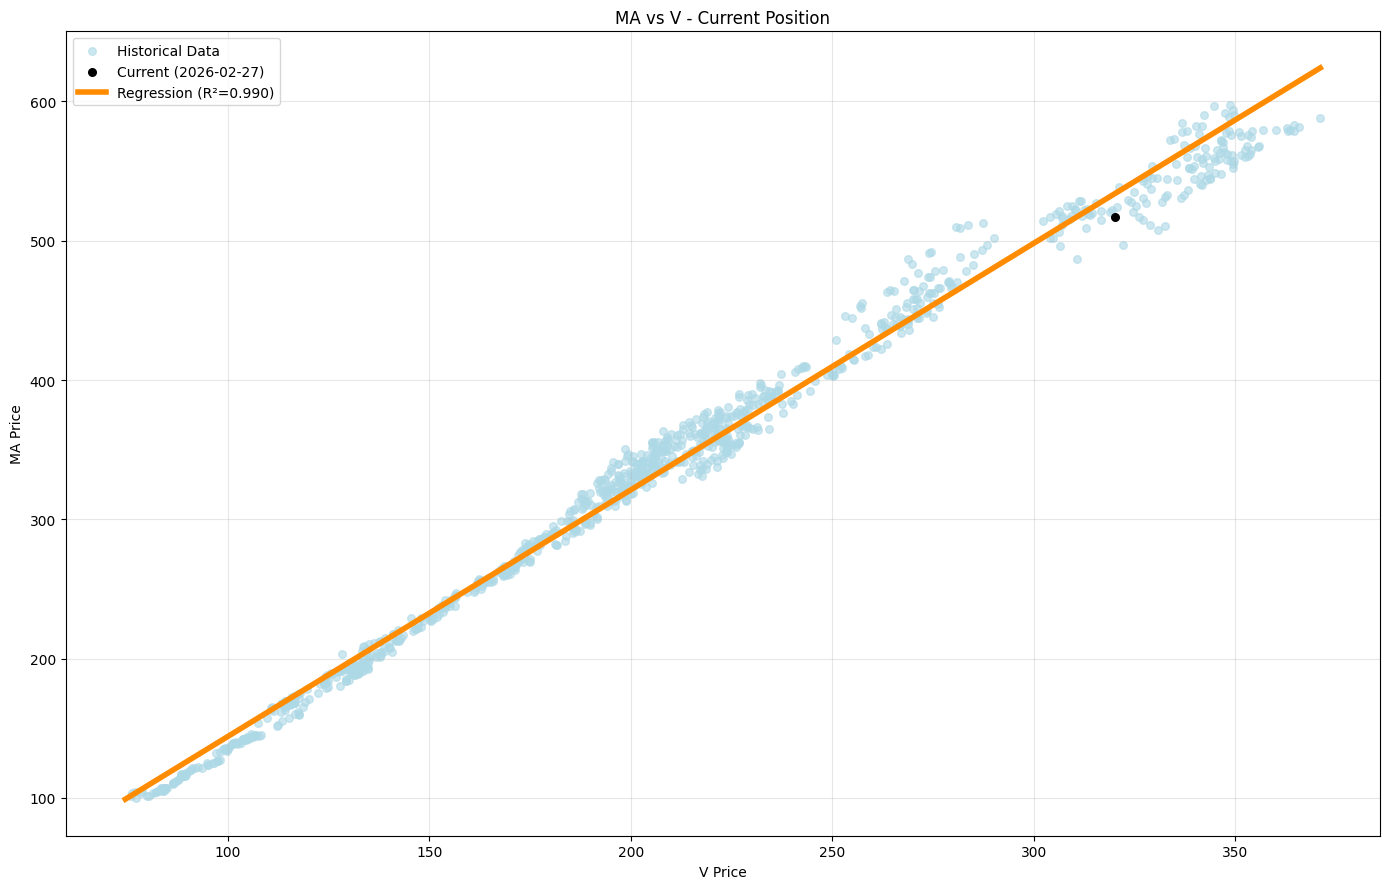

In [39]:
plt.figure(figsize=(14, 9))

# Sample historical data (max 1000 points)
sample_size = min(1000, len(df)-1)
df_sample = df.sample(n=sample_size, random_state=42)

# Historical points (light blue)
plt.scatter(df_sample[asset2_col], df_sample[asset1_col], 
            alpha=0.6, s=30, label='Historical Data', color='lightblue')

# Current point (black, same size)
current_point = df.iloc[-1]
plt.scatter(current_point[asset2_col], current_point[asset1_col], 
            color='black', s=30, label=f'Current ({current_point.name.strftime("%Y-%m-%d")})', zorder=5)

# Regression line
x_range = np.linspace(df[asset2_col].min(), df[asset2_col].max(), 100)
y_pred = model.predict(x_range.reshape(-1, 1))
plt.plot(x_range, y_pred, color='darkorange', linewidth=4, 
         label=f'Regression (R²={r2:.3f})')

plt.xlabel(f'{asset2_col} Price')
plt.ylabel(f'{asset1_col} Price')
plt.title(f'{asset1_col} vs {asset2_col} - Current Position')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distance from regression line
current_pred = model.predict([[current_point[asset2_col]]])[0]
distance = abs(current_point[asset1_col] - current_pred)

/home/charly/Documents/Projets/quant-personal-tests/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


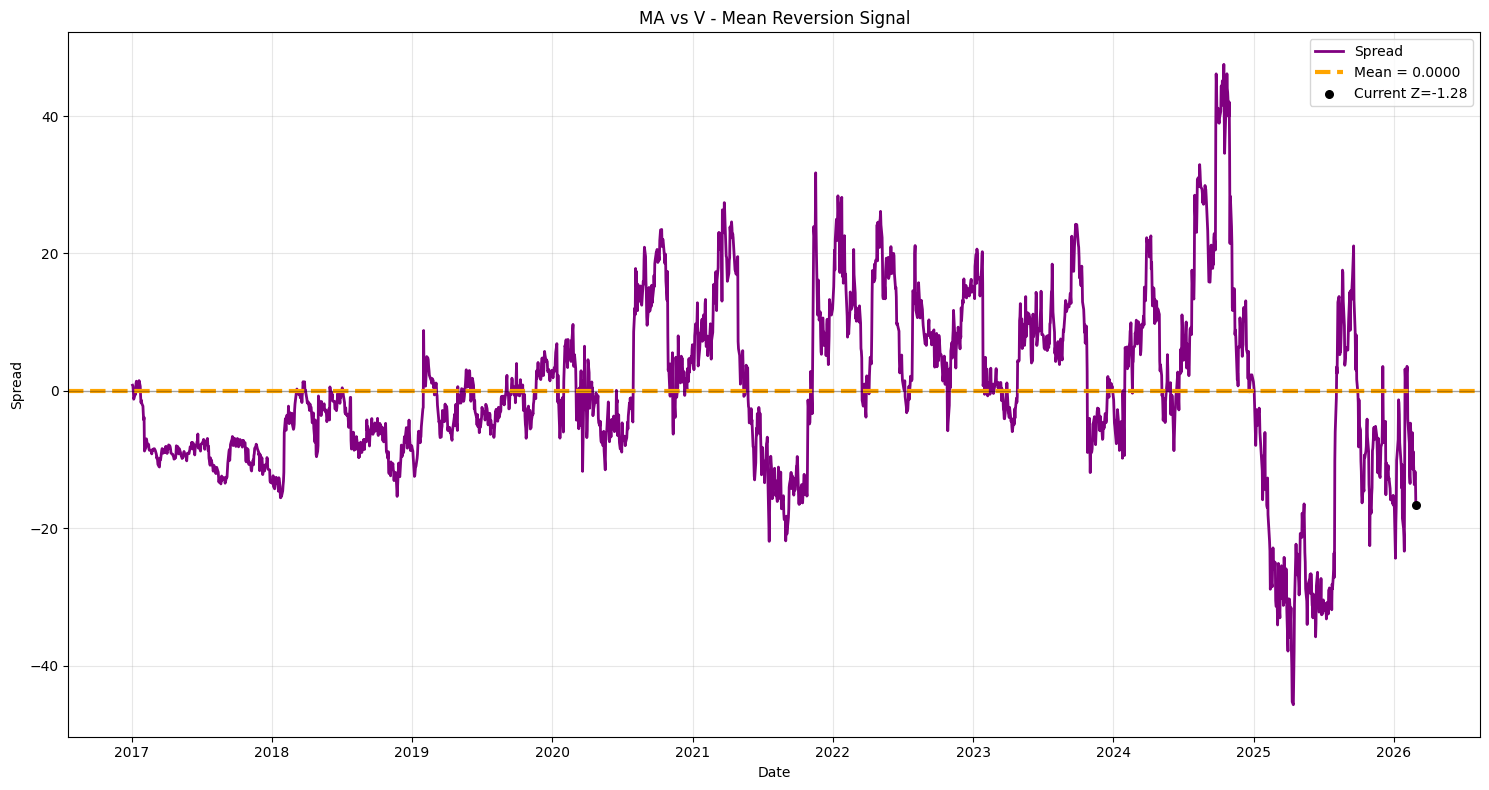

In [40]:
# Calculate spread locally
spread = df[asset1_col] - model.predict(df[[asset2_col]])
mean_spread = spread.mean()
std_spread = spread.std()
z_score = (spread.iloc[-1] - mean_spread) / std_spread

fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Plot spread
ax.plot(df.index, spread, linewidth=2, color='purple', label='Spread')
ax.axhline(y=mean_spread, color='orange', linewidth=3, linestyle='--', 
           label=f'Mean = {mean_spread:.4f}')
ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.3)

# Current point
ax.scatter(df.index[-1], spread.iloc[-1], color='black', s=30, zorder=5,
           label=f'Current Z={z_score:.2f}')

ax.set_title(f'{asset1_col} vs {asset2_col} - Mean Reversion Signal')
ax.set_xlabel('Date')
ax.set_ylabel('Spread')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

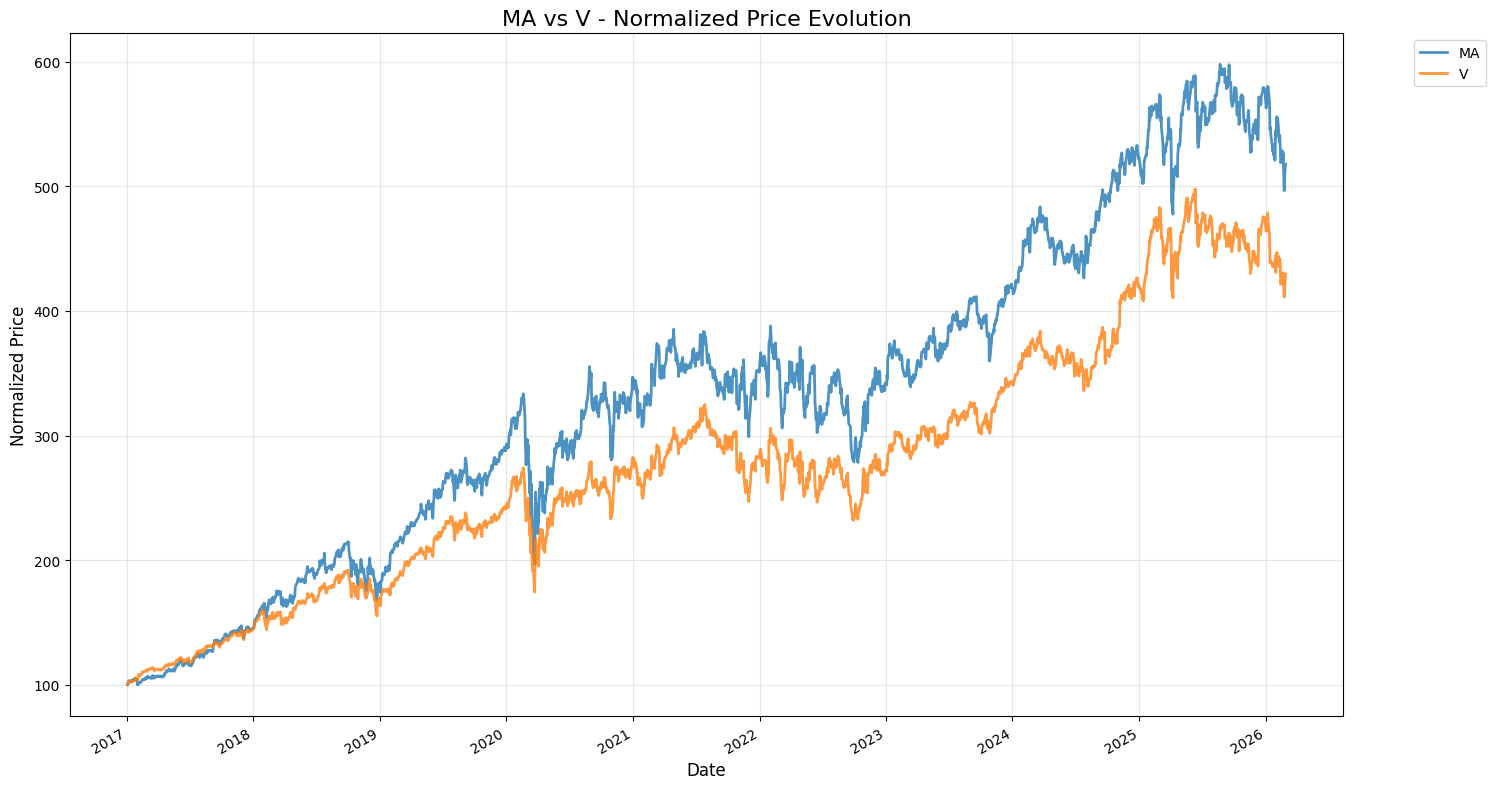

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Normalize to 100 (just the two price curves)
normalized_prices = (df / df.iloc[0]) * 100
normalized_prices.plot(ax=ax, linewidth=2, alpha=0.8)

ax.set_title(f'{asset1_col} vs {asset2_col} - Normalized Price Evolution', fontsize=16)
ax.set_ylabel('Normalized Price', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
z_score = (spread.iloc[-1] - mean_spread) / std_spread

print("🎯 MEAN REVERSION STRATEGY SIGNALS")
print("=" * 60)
print(f"Pair: {asset1_col} vs {asset2_col}")
print(f"Current Z-Score: {z_score:.2f}")
print()

if z_score > 1.8:
    print("🔴 SELL SIGNAL")
    print(f"  → {asset1_col} is {z_score:.1f}σ ABOVE mean → OVERVALUED")
    print(f"  → SHORT {asset1_col} / LONG {asset2_col}")
    print("  → Target: Z-Score = 0 (mean reversion)")
    
elif z_score < -1.8:
    print("🟢 BUY SIGNAL") 
    print(f"  → {asset1_col} is {z_score:.1f}σ BELOW mean → UNDERVALUED")
    print(f"  → LONG {asset1_col} / SHORT {asset2_col}")
    print("  → Target: Z-Score = 0 (mean reversion)")
    
else:
    print("🟡 NEUTRAL")
    print(f"  → Z-Score {z_score:.1f} within normal range [-1.8, +1.8]")
    print("  → No trade signal - wait for extreme deviation")

print(f"\n📊 Stats Summary:")
print(f"   R²: {r2:.3f} (regression quality)")
print(f"   Mean spread: {mean_spread:.4f}")
print(f"   Current spread: {spread.iloc[-1]:.4f}")
print(f"   Distance to mean: {abs(spread.iloc[-1] - mean_spread):.4f}")

🎯 MEAN REVERSION STRATEGY SIGNALS
Pair: MA vs V
Current Z-Score: -1.28

🟡 NEUTRAL
  → Z-Score -1.3 within normal range [-1.8, +1.8]
  → No trade signal - wait for extreme deviation

📊 Stats Summary:
   R²: 0.990 (regression quality)
   Mean spread: 0.0000
   Current spread: -16.5746
   Distance to mean: 16.5746
